# Olist Brazilian E-Commerce 数据分析

核心表：订单表、订单商品明细表、订单支付表、客户表
补充分析表：卖家表、评论表、产品表、地理位置表

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [2]:
import os
os.getcwd()

'/Users/ggc/python learning/GGCHENINE/olist_brazilian_ecommerce'

In [3]:
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## 订单量分析

orders：一行代表一笔订单。

order_items：一行代表某个订单中的一个商品明细项    

order_payments：一行代表某笔订单中的一条支付记录  

customers：一行代表一个客户信息记录  



orders -> order_items：一对多，一笔订单对应多笔订单商品。

orders -> order_payments：一对多，可能存在多条支付记录，分次支付等。

orders -> customers：多对一，客户多次下单。

In [8]:
# 判断是否唯一
print(orders['order_id'].nunique())
print(len(orders))
len(orders) == orders['order_id'].nunique()
# orders 表里每一行对应一个不同的订单。

99441
99441


True

In [9]:
orders.shape
# 99441行8列

(99441, 8)

In [10]:
print(len(order_items))
print(order_items['order_id'].nunique())
# 同一个 order_id 在 order_items 里出现了多次。一笔订单可能对应多个商品明细项。



112650
98666


In [11]:
print(len(order_payments))
print(order_payments['order_id'].nunique())
# 同一个订单在支付表里可能有多条记录。

103886
99440


In [12]:
print(len(customers))
print(customers['customer_id'].nunique())
# customer_id在客户表中唯一

99441
99441


In [13]:
# 通过GROUP BY 分组控制颗粒度
# 联动sql
conn = sqlite3.connect(':memory:')
orders.to_sql('orders', conn, index=False, if_exists='replace')

99441

In [14]:
query = '''
SELECT 
    order_status,
    COUNT(*) AS order_count
FROM
    orders
GROUP BY order_status
ORDER BY order_count DESC
'''
pd.read_sql(query,conn)
# 应当仅关注已交付

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [15]:
status_df = pd.read_sql(query,conn)
status_df['order_percent'] = status_df['order_count'] / status_df['order_count'].sum()
status_df

,order_status,order_count,order_percent
0,delivered,96478,0.970203
1,shipped,1107,0.011132
2,canceled,625,0.006285
3,unavailable,609,0.006124
4,invoiced,314,0.003158
5,processing,301,0.003027
6,created,5,0.000050
7,approved,2,0.000020


## 销售额分析

In [16]:
# 订单量月度趋势分析 按订单产生日期确定
orders.head()
query = '''
SELECT 
    strftime('%Y-%m',order_purchase_timestamp) AS purchase_time,
    COUNT(*) AS order_cnt
FROM 
    orders
GROUP BY purchase_time
ORDER BY purchase_time ASC
'''
purchase_df = pd.read_sql(query,conn)
display(purchase_df)
purchase_df.dtypes

,purchase_time,order_cnt
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


purchase_time      str
order_cnt        int64
dtype: object

In [17]:
# 将字符串转化为日期格式
purchase_df['purchase_time'] = pd.to_datetime(purchase_df['purchase_time'])
purchase_df.dtypes

purchase_time    datetime64[us]
order_cnt                 int64
dtype: object

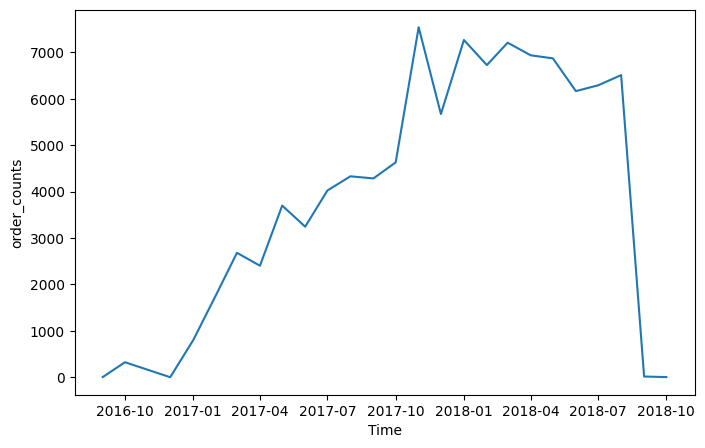

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(purchase_df['purchase_time'], purchase_df['order_cnt'])
plt.xlabel('Time')
plt.ylabel('order_counts')
plt.show()


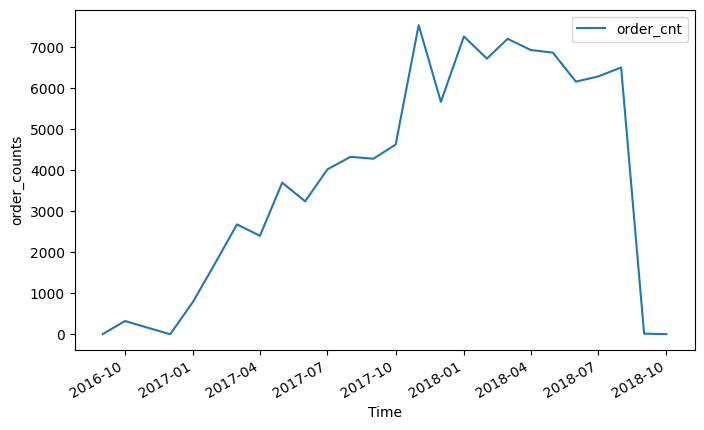

In [19]:
purchase_df.plot(x='purchase_time', y='order_cnt', kind='line', figsize=(8, 5))
plt.xlabel('Time')
plt.ylabel('order_counts')
plt.show()


In [20]:
# 计算平台销售额
display(orders.sort_values('order_delivered_customer_date').head())
display(order_items.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
59102,36989eb07a0de2d3d3129eea35553875,aadd27185177fc7ac9b364898ac09343,delivered,2016-10-04 13:11:29,2016-10-04 13:46:31,2016-10-08 13:46:32,2016-10-11 13:46:32,2016-12-06 00:00:00
1384,7033745709b7cf1bac7d2533663592de,7f0ca17bb33b230b47459437cf0682c7,delivered,2016-10-04 14:13:22,2016-10-04 14:46:48,2016-10-08 14:46:49,2016-10-11 14:46:49,2016-11-30 00:00:00
56143,d1eb8e4e276a4eea13a5c462c0765e60,9031f9dcde5860b34e6c65ac5c796d30,delivered,2016-10-04 19:30:28,2016-10-06 03:10:33,2016-10-10 03:10:34,2016-10-13 03:10:34,2016-12-06 00:00:00
52382,92b44b87f1f7670b8911c5f0e642435e,e561a3f61440b031d3be286a696d06eb,delivered,2016-10-05 11:08:46,2016-10-06 07:45:47,2016-10-10 07:45:48,2016-10-13 07:45:48,2016-11-25 00:00:00
699,ac2b7c522d811acba0aa270ed3e112e4,ef21aebbb093a6db29ccc6aa0b89c347,delivered,2016-10-05 15:08:00,2016-10-06 15:44:26,2016-10-10 15:44:27,2016-10-13 15:44:27,2016-11-29 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [21]:
order_items.to_sql('order_items', conn, index=False, if_exists='replace')
order_payments.to_sql('order_payments',conn,index=False,if_exists='replace')

103886

In [22]:
query = '''
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    COALESCE(SUM(i.price),0) AS total_sales
FROM orders AS o
LEFT JOIN order_items AS i
ON o.order_id = i.order_id
WHERE o.order_status = 'delivered'
GROUP BY strftime('%Y-%m', o.order_purchase_timestamp)
ORDER BY month;
'''

price_sell = pd.read_sql(query,conn)
price_sell

,month,total_sales
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


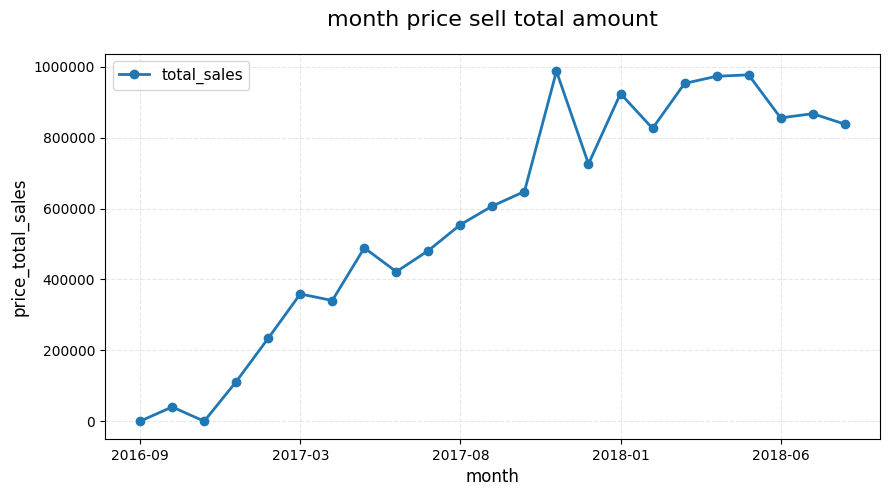

In [23]:
ax = price_sell.plot.line(x="month",figsize=(10,5),linewidth=2,marker='o')

ax.set_title('month price sell total amount',fontsize=16,pad=20)
ax.set_xlabel('month',fontsize=12)
ax.set_ylabel('price_total_sales',fontsize=12)
ax.grid(alpha=0.3,linestyle='--')
ax.legend(fontsize=11,loc='upper left')
ax.ticklabel_format(style='plain', axis='y')
plt.show()

In [24]:
pd.set_option('display.float_format', '{:.2f}'.format)


In [25]:
# 按月统计 delivered 订单的 price + freight_value 总额
query2 = '''
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    COALESCE(SUM(i.price + i.freight_value),0) AS total_sales
FROM orders AS o
LEFT JOIN order_items AS i
ON o.order_id = i.order_id
WHERE o.order_status = 'delivered'
GROUP BY strftime('%Y-%m', o.order_purchase_timestamp)
ORDER BY month;
'''
total_sell = pd.read_sql(query2,conn)
total_sell

,month,total_sales
0,2016-09,143.46
1,2016-10,46490.66
2,2016-12,19.62
3,2017-01,127482.37
4,2017-02,271239.32
5,2017-03,414330.95
6,2017-04,390812.40
7,2017-05,566851.40
8,2017-06,490050.37
9,2017-07,566299.08


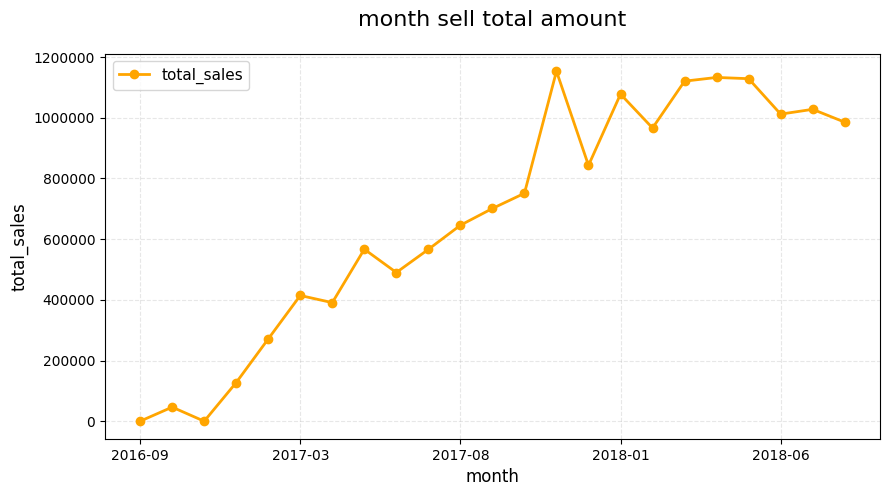

In [26]:
ax = total_sell.plot.line(x="month",figsize=(10,5),linewidth=2,marker='o',color='orange')

ax.set_title('month sell total amount',fontsize=16,pad=20)
ax.set_xlabel('month',fontsize=12)
ax.set_ylabel('total_sales',fontsize=12)
ax.grid(alpha=0.3,linestyle='--')
ax.legend(fontsize=11,loc='upper left')
ax.ticklabel_format(style='plain', axis='y')
plt.show()

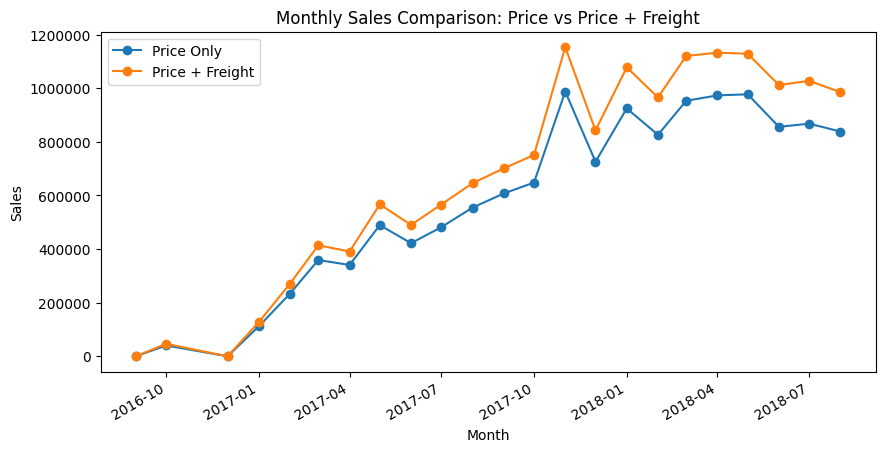

In [27]:
# 先区分两张表中的金额列名
price_sell = price_sell.rename(columns={'total_sales': 'price_sales'})
total_sell = total_sell.rename(columns={'total_sales': 'price_freight_sales'})

# 按 month 合并
compare_df = pd.merge(price_sell, total_sell, on='month')

# 转成日期类型，方便绘图
compare_df['month'] = pd.to_datetime(compare_df['month'])

# 画对比折线图
ax = compare_df.plot(
    x='month',
    y=['price_sales', 'price_freight_sales'],
    kind='line',
    figsize=(10, 5),
    marker='o'
)

ax.ticklabel_format(style='plain', axis='y')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Comparison: Price vs Price + Freight')
plt.legend(['Price Only', 'Price + Freight'])
plt.show()


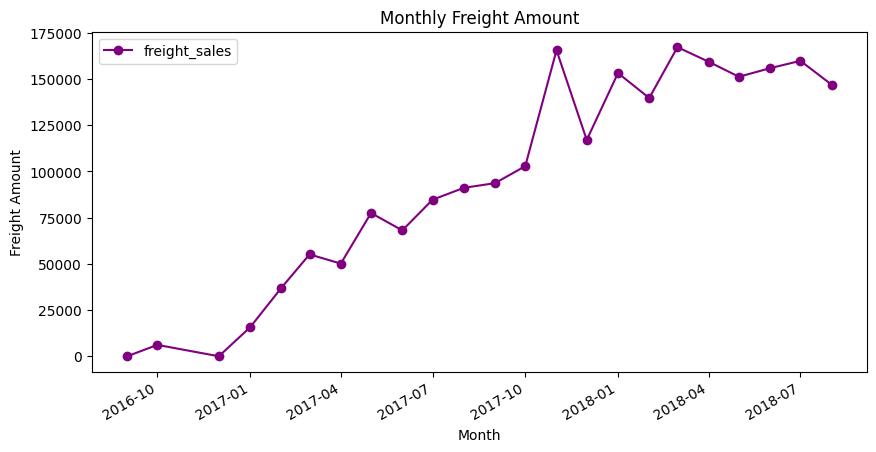

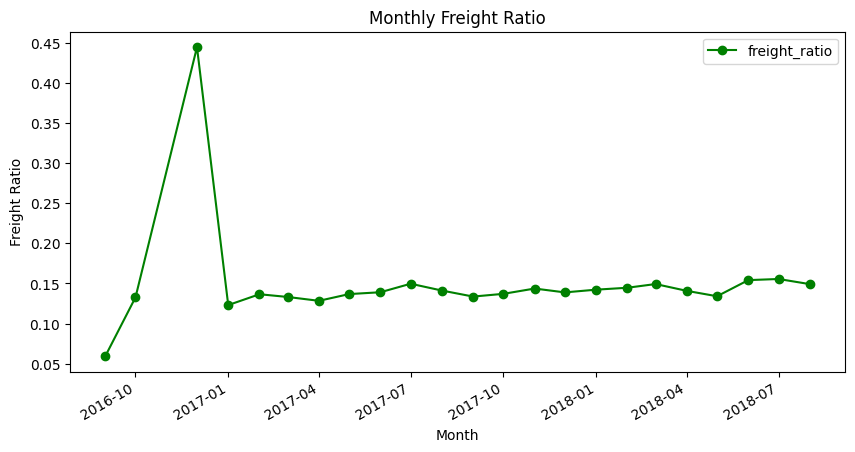

In [28]:
# 计算运费金额和运费占比
compare_df['freight_sales'] = compare_df['price_freight_sales'] - compare_df['price_sales']
compare_df['freight_ratio'] = compare_df['freight_sales'] / compare_df['price_freight_sales']

# 让占比结果更好读
compare_df['freight_ratio'] = compare_df['freight_ratio'].round(4)

compare_df
ax = compare_df.plot(
    x='month',
    y='freight_sales',
    kind='line',
    figsize=(10, 5),
    marker='o',
    color='purple'
)

ax.ticklabel_format(style='plain', axis='y')
plt.xlabel('Month')
plt.ylabel('Freight Amount')
plt.title('Monthly Freight Amount')
plt.show()
ax = compare_df.plot(
    x='month',
    y='freight_ratio',
    kind='line',
    figsize=(10, 5),
    marker='o',
    color='green'
)

plt.xlabel('Month')
plt.ylabel('Freight Ratio')
plt.title('Monthly Freight Ratio')
plt.show()



### 运费金额与运费占比分析

为了进一步理解运费对平台订单金额的影响，这里将“仅商品金额”与“商品金额+运费”两种口径进行对比，并计算每个月的运费金额与运费占比。

运费金额的计算方式为：

`freight_sales = price_freight_sales - price_sales`

运费占比的计算方式为：

`freight_ratio = freight_sales / price_freight_sales`

从结果看，加入运费后，各月总金额整体都高于仅统计商品价格时的金额，说明运费是订单总金额中不可忽视的一部分。

在月度运费占比趋势中，个别月份出现了较高的占比峰值，例如最高接近 `0.45`。这并不一定说明该月份物流成本异常高，更可能是因为该月总样本量较小、商品销售额本身较低，导致运费在总金额中的占比被放大。

例如，某些早期月份的总销售额较低，此时即使运费绝对值不高，也可能让占比明显上升。因此，在解读运费占比时，不能只看比例的高低，还需要结合当月的总销售额或订单量一起判断。

总体来看，平台月度金额趋势主要仍由商品销售额驱动，运费会抬高总金额水平，但没有改变整体趋势方向。




## 支付分析
#   不同支付方式的订单分布

In [29]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [30]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [31]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [32]:
query = '''
SELECT 
    payment_type,
    COUNT(payment_type) AS payment_channel
FROM
    order_payments
GROUP BY payment_type
ORDER BY COUNT(payment_type) DESC
;
'''
pay_channel = pd.read_sql(query,conn)
pay_channel['channel_pct'] = pay_channel['payment_channel'] / pay_channel['payment_channel'].sum()
pay_channel

,payment_type,payment_channel,channel_pct
0,credit_card,76795,0.74
1,boleto,19784,0.19
2,voucher,5775,0.06
3,debit_card,1529,0.01
4,not_defined,3,0.00


### 不同支付方式对应的支付金额

In [33]:
query = '''
SELECT 
    payment_type,
    COUNT(payment_type) AS payment_channel_count,
    COALESCE(SUM(payment_value),0) AS pay_channel_amtsum
FROM
    order_payments
GROUP BY payment_type
ORDER BY COUNT(payment_type) DESC
;
'''
pay_sum = pd.read_sql(query,conn)
pay_sum['channel_pct'] = pay_sum['payment_channel_count'] / pay_sum['payment_channel_count'].sum()
display(pay_sum)
pay_sum['amount_pct'] = pay_sum['pay_channel_amtsum'] / pay_sum['pay_channel_amtsum'].sum()


,payment_type,payment_channel_count,pay_channel_amtsum,channel_pct
0,credit_card,76795,12542084.19,0.74
1,boleto,19784,2869361.27,0.19
2,voucher,5775,379436.87,0.06
3,debit_card,1529,217989.79,0.01
4,not_defined,3,0.00,0.00


In [34]:
pay_sum['avg_amount'] = pay_sum['pay_channel_amtsum'] / pay_sum['payment_channel_count']
pay_sum

,payment_type,payment_channel_count,pay_channel_amtsum,channel_pct,amount_pct,avg_amount
0,credit_card,76795,12542084.19,0.74,0.78,163.32
1,boleto,19784,2869361.27,0.19,0.18,145.03
2,voucher,5775,379436.87,0.06,0.02,65.70
3,debit_card,1529,217989.79,0.01,0.01,142.57
4,not_defined,3,0.00,0.00,0.00,0.00


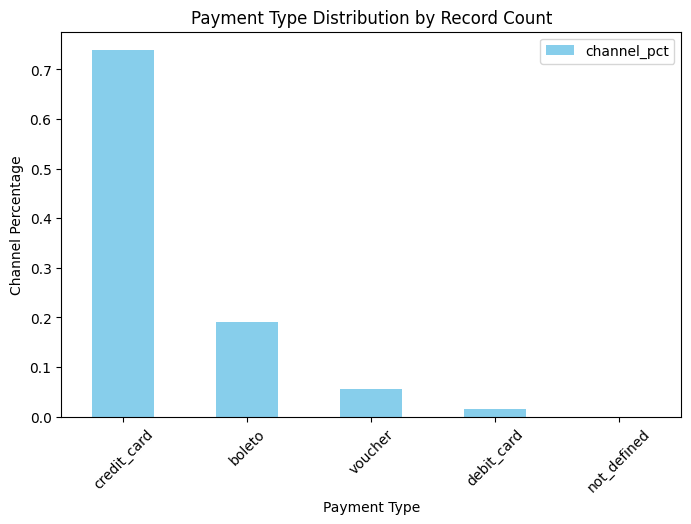

In [35]:
ax = pay_sum.plot(
    x='payment_type',
    y='channel_pct',
    kind='bar',
    figsize=(8, 5),
    color='skyblue'
)

plt.xlabel('Payment Type')
plt.ylabel('Channel Percentage')
plt.title('Payment Type Distribution by Record Count')
plt.xticks(rotation=45)
plt.show()


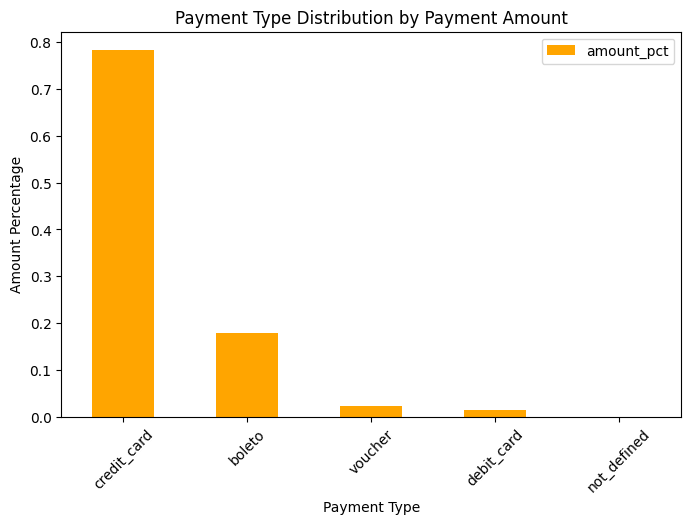

In [36]:
ax = pay_sum.plot(
    x='payment_type',
    y='amount_pct',
    kind='bar',
    figsize=(8, 5),
    color='orange'
)

plt.xlabel('Payment Type')
plt.ylabel('Amount Percentage')
plt.title('Payment Type Distribution by Payment Amount')
plt.xticks(rotation=45)
plt.show()


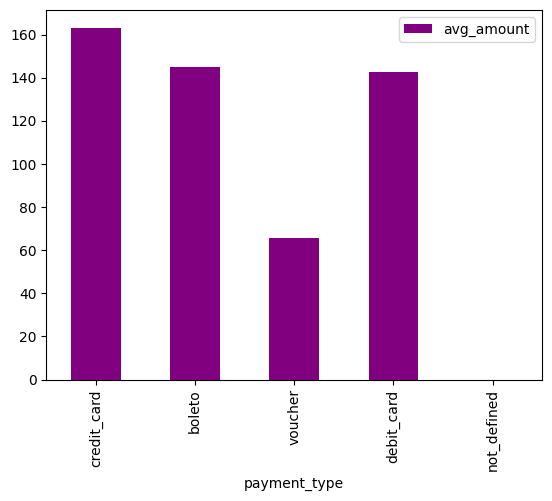

In [37]:
ax = pay_sum.plot(x="payment_type",y='avg_amount',kind='bar',color='purple')

## 不同分期数的出现次数，不同分期的平均订单金额

In [38]:
order_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [39]:
query = '''
SELECT
    payment_installments,
    COUNT(*) AS installment_count,
    COALESCE(SUM(payment_value), 0) AS total_payment_value,
    AVG(payment_value) AS avg_payment_value
FROM order_payments
WHERE payment_type = 'credit_card'
GROUP BY payment_installments
ORDER BY payment_installments
'''
installment_df = pd.read_sql(query, conn)
installment_df


,payment_installments,installment_count,total_payment_value,avg_payment_value
0,0,2,188.63,94.31
1,1,25455,2440445.43,95.87
2,2,12413,1579283.03,127.23
3,3,10461,1491103.80,142.54
4,4,7098,1163907.61,163.98
5,5,5239,961174.30,183.47
6,6,3920,822611.81,209.85
7,7,1626,305157.39,187.67
8,8,4268,1313423.34,307.74
9,9,644,131015.92,203.44


In [40]:
installment_df.describe()

,payment_installments,installment_count,total_payment_value,avg_payment_value
count,24.00,24.00,24.00,24.00
mean,11.71,3199.79,522586.84,259.60
std,7.37,5929.39,774708.50,151.18
min,0.00,1.00,188.63,94.31
25%,5.75,13.25,2171.42,160.60
50%,11.50,50.50,23052.99,206.65
75%,17.25,4510.75,1011857.63,311.22
max,24.00,25455.00,2440445.43,615.80


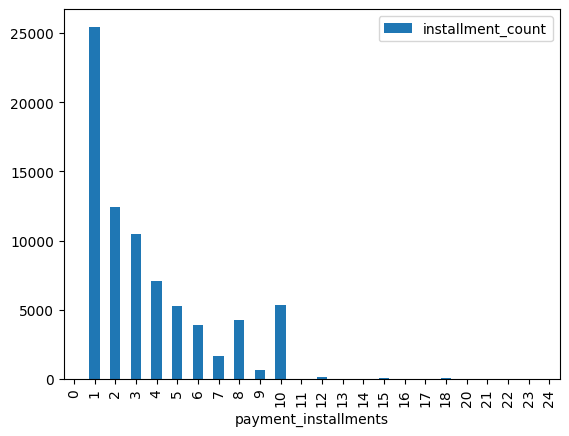

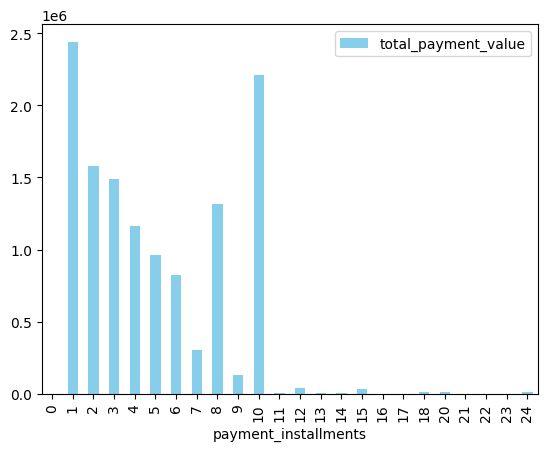

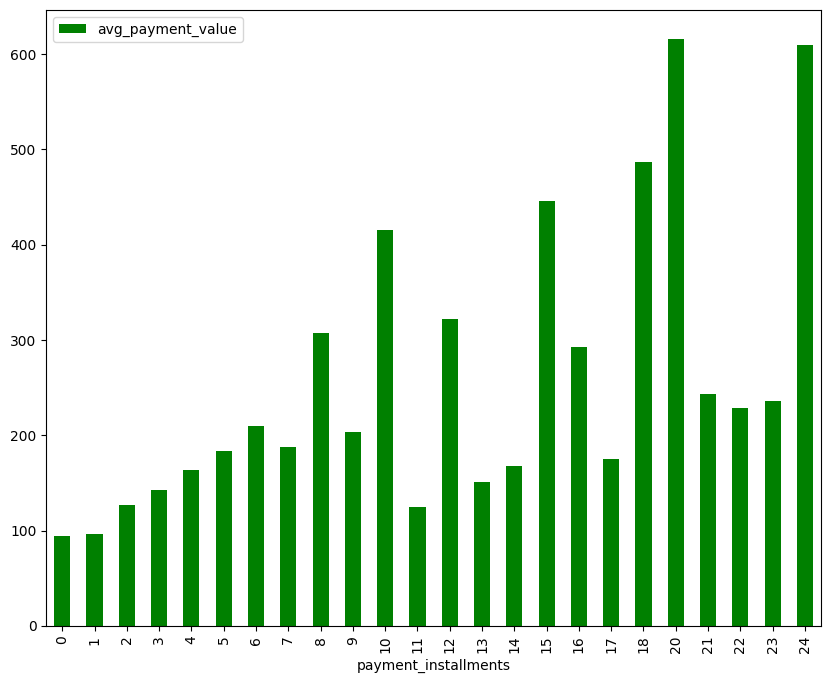

In [41]:
ax1 = installment_df.plot(x='payment_installments',y='installment_count',kind='bar')
ax2 = installment_df.plot(x='payment_installments',y='total_payment_value',kind='bar',color='skyblue')
ax3 = installment_df.plot(x='payment_installments',y='avg_payment_value',kind='bar',color='green',figsize=(10,8))

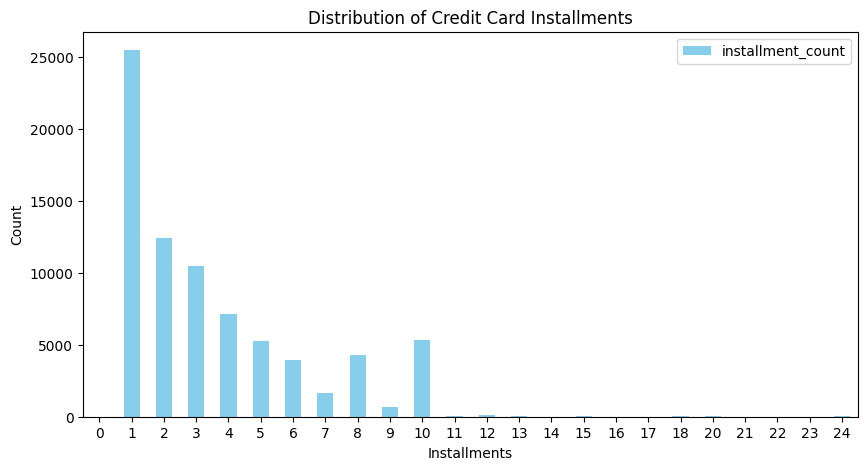

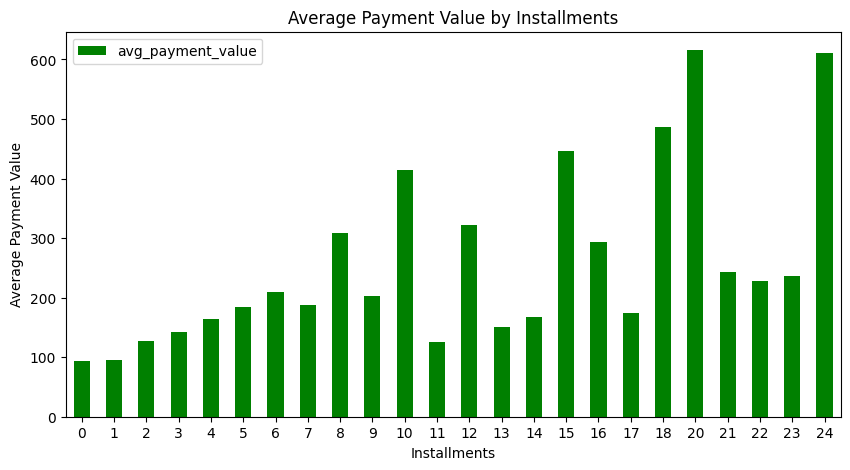

In [42]:
ax1 = installment_df.plot(
    x='payment_installments',
    y='installment_count',
    kind='bar',
    color='skyblue',
    figsize=(10, 5)
)
plt.xlabel('Installments')
plt.ylabel('Count')
plt.title('Distribution of Credit Card Installments')
plt.xticks(rotation=0)
plt.show()

ax2 = installment_df.plot(
    x='payment_installments',
    y='avg_payment_value',
    kind='bar',
    color='green',
    figsize=(10, 5)
)
ax2.ticklabel_format(style='plain', axis='y')
plt.xlabel('Installments')
plt.ylabel('Average Payment Value')
plt.title('Average Payment Value by Installments')
plt.xticks(rotation=0)
plt.show()


从支付总金额分布看，信用卡支付金额主要集中在 `1` 期及中低分期区间，说明平台的大部分信用卡交易仍主要由低分期方式贡献。

同时，较高分期数的支付记录数量相对较少，对应的总支付金额也较低，但其平均支付金额相对更高。这说明高分期支付虽然不是主流方式，却更多出现在高金额支付场景中。

综合来看，平台用户在信用卡支付中整体更偏向低分期，但当订单金额较高时，用户更倾向于选择较高分期数来分摊支付压力。


In [43]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [44]:
customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

customer_id 是订单层面的客户记录编号  

customer_unique_id 是同一个真实用户的统一编号

In [49]:
customers.to_sql('customers', conn, index=False, if_exists='replace')


99441

In [52]:
query = '''
SELECT 
    COUNT(DISTINCT customer_unique_id) AS user_id
FROM 
    customers;
'''
user_id = pd.read_sql(query,conn)
user_id


,user_id
0,96096


### 复购用户分析

In [54]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [56]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [85]:
query='''
SELECT 
    COALESCE(COUNT(o.order_id),0) AS order_count,
    c.customer_unique_id
FROM 
    customers AS c
LEFT JOIN 
    orders AS o
ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
'''

order_count = pd.read_sql(query,conn)

In [86]:
order_count.head()

,order_count,customer_unique_id
0,1,0000366f3b9a7992bf8c76cfdf3221e2
1,1,0000b849f77a49e4a4ce2b2a4ca5be3f
2,1,0000f46a3911fa3c0805444483337064
3,1,0000f6ccb0745a6a4b88665a16c9f078
4,1,0004aac84e0df4da2b147fca70cf8255


In [87]:
order_count.describe()

,order_count
count,96096.00
mean,1.03
std,0.21
min,1.00
25%,1.00
50%,1.00
75%,1.00
max,17.00


In [88]:
# 总用户
total_users =  len(order_count)

# 复购用户数
x =  len(order_count[order_count['order_count'] > 1])

# 复购率
repurchase_rate = x /total_users

display(total_users,x,repurchase_rate)

96096

2997

0.031187562437562436

In [89]:
repurchase_rate_df = pd.DataFrame({
    'metric' : ['total_users','x','repurchase_rate'],
    'value':[total_users,x,repurchase_rate]})
repurchase_rate_df

,metric,value
0,total_users,96096.00
1,x,2997.00
2,repurchase_rate,0.03


复购率为3%，平台以一次性客户为主

In [90]:
order_dist = order_count['order_count'].value_counts().sort_index()
order_dist


order_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

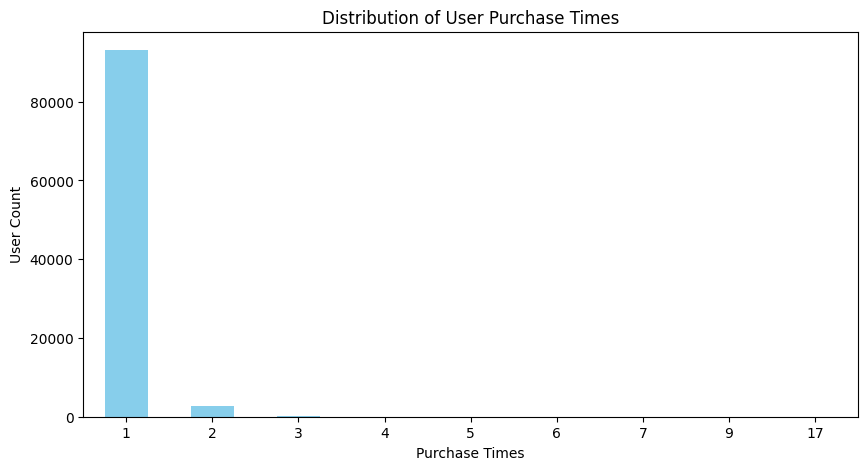

In [91]:
ax = order_dist.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.xlabel('Purchase Times')
plt.ylabel('User Count')
plt.title('Distribution of User Purchase Times')
plt.xticks(rotation=0)
plt.show()


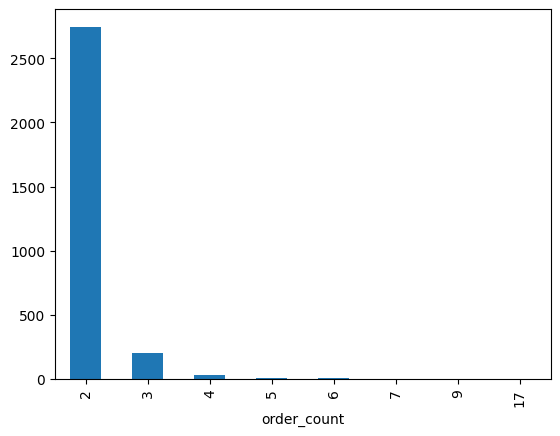

In [92]:
order_dist_filtered = order_dist[order_dist.index != 1]
order_dist_filtered.plot(kind='bar')
plt.show()


### 用户下单次数分布分析

为了进一步观察平台用户的购买行为，这里基于 `customer_unique_id` 统计每位真实用户的下单次数，并分析不同下单次数对应的用户数量分布。

结果显示，平台用户的下单次数高度集中在 `1` 次，说明绝大多数用户只完成了一次购买行为，平台整体以一次性购买用户为主。这与前面计算出的复购率约为 `3%` 的结果一致，说明复购用户占比相对较低。

从分布形态看，用户数量会随着下单次数增加而快速下降，呈现明显的长尾特征。也就是说，下单次数越多的用户越少，只有极少数用户会多次重复购买。

在去掉下单 1 次的用户后，复购用户内部的分布依然表现出类似特征：低复购次数用户相对更多，而高频复购用户数量非常有限。这说明平台虽然存在复购行为，但复购深度整体不高，用户持续购买能力仍然较弱。

综合来看，当前平台订单主要依赖首次购买用户贡献，用户留存和复购表现相对有限。后续如果从运营角度出发，可以进一步结合地区、商品类别、评价等维度，分析哪些因素可能影响用户复购。


## 地区分析

In [93]:
customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [101]:
# 使用pandas制作子表
order_customer_df = pd.merge(
    orders,
    customers,
    on='customer_id',
    how='left'
)
order_customer_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


按照州统计订单量

In [102]:
state_order = order_customer_df.groupby('customer_state')['order_id'].count().sort_values(ascending=False)
state_order

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: order_id, dtype: int64

In [106]:
state_order_pct = (state_order / state_order.sum()).round(4)
state_order_pct

customer_state
SP   0.42
RJ   0.13
MG   0.12
RS   0.06
PR   0.05
SC   0.04
BA   0.03
DF   0.02
ES   0.02
GO   0.02
PE   0.02
CE   0.01
PA   0.01
MT   0.01
MA   0.01
MS   0.01
PB   0.01
PI   0.01
RN   0.00
AL   0.00
SE   0.00
TO   0.00
RO   0.00
AM   0.00
AC   0.00
AP   0.00
RR   0.00
Name: order_id, dtype: float64

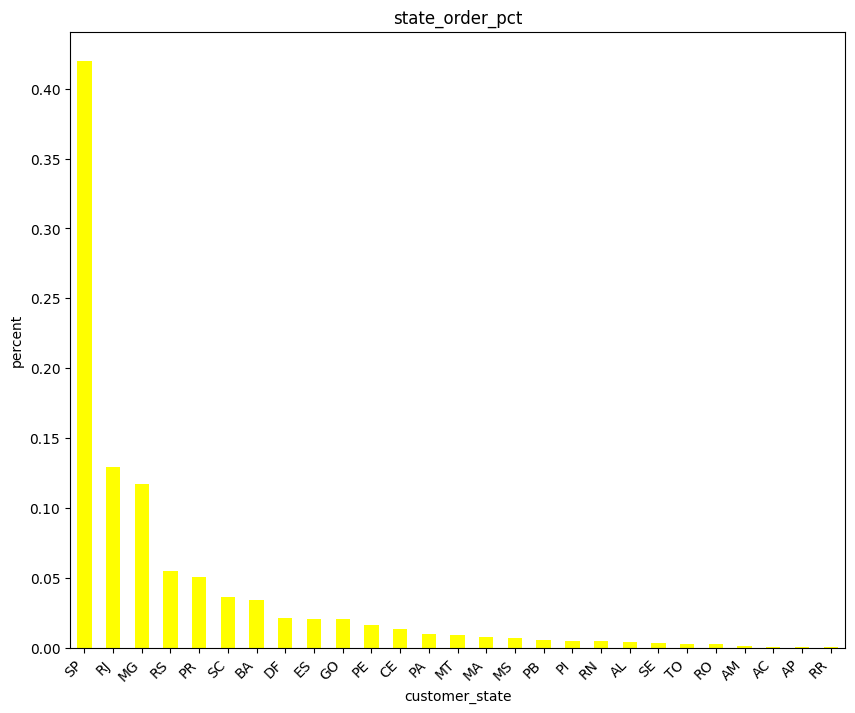

In [113]:
ax = state_order_pct.plot(kind='bar',color='yellow',figsize=(10,8))
ax.set_title('state_order_pct')
ax.set_ylabel('percent')
plt.xticks(rotation=45,ha='right');

### 各州订单占比分布分析

从各州订单占比分布来看，平台订单明显集中在少数核心州，其中 `SP` 州订单占比最高，远高于其他地区，说明平台订单来源具有较强的地区集中性。

`RJ` 和 `MG` 位于第二梯队，订单占比也相对较高，但与 `SP` 之间仍存在明显差距。其余州的订单占比整体较低，呈现出明显的长尾分布特征。

整体来看，平台订单主要由少数核心州贡献，尤其是 `SP` 州在平台订单结构中占据主导地位。这说明后续在做地区分析时，可以优先重点关注头部州的用户、销售额和商品表现。


In [116]:
# 按城市分类统计订单量
order_customer_city = order_customer_df.groupby('customer_city')['order_id'].count().sort_values(ascending=False)
order_customer_city.count()

np.int64(4119)

In [117]:
order_customer_city

customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
                  ...  
ibiara                1
rio espera            1
rio dos indios        1
rio dos cedros        1
lagoao                1
Name: order_id, Length: 4119, dtype: int64

In [ ]:
# 查看SP州城市订单占比
sp_city_order = (
     order_customer_df[order_customer_df['customer_state'] == 'SP']
    .groupby('customer_city')['order_id']
    .count()
    .sort_values(ascending=False)
)
sp_city_order.head(10)

customer_city
sao paulo                15540
campinas                  1444
guarulhos                 1189
sao bernardo do campo      938
santo andre                796
osasco                     746
santos                     713
sao jose dos campos        691
sorocaba                   633
jundiai                    565
Name: order_id, dtype: int64

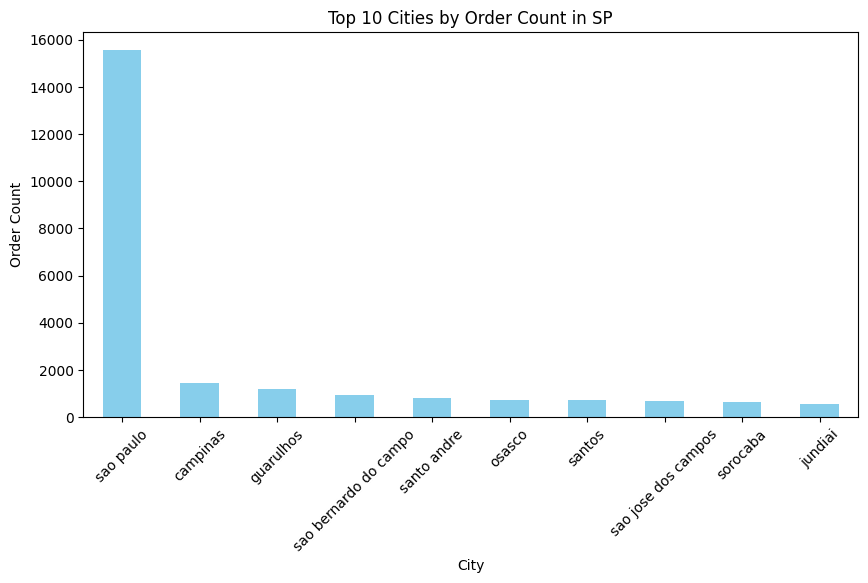

In [ ]:
sp_city_top10 = sp_city_order.head(10)

ax = sp_city_top10.plot(
    kind='bar',
    figsize=(10, 5),
    color='skyblue'
)

ax.ticklabel_format(style='plain', axis='y')
plt.xlabel('City')
plt.ylabel('Order Count')
plt.title('Top 10 Cities by Order Count in SP')
plt.xticks(rotation=45)
plt.show()


### SP 州内城市订单分布分析

在 `SP` 州内部进一步按城市统计订单量后可以发现，`sao paulo` 市的订单数量远高于其他城市，表现出非常明显的领先优势。这说明 `SP` 州的订单并不是平均分布在各城市之间，而是高度集中在核心城市。

从其余进入前 10 的城市来看，`campinas`、`guarulhos`、`sao bernardo do campo` 等城市也具有一定订单规模，但与 `sao paulo` 市相比仍存在明显差距，整体呈现出较强的头部集中现象。

综合州层面和州内城市层面的结果来看，平台订单在地区分布上具有明显的层级集中性：一方面集中在少数头部州，另一方面在头部州内部又集中在少数核心城市。


## 按州统计订单销售额（delivered）

In [122]:
display(orders.head())    # 订单表前5行
display(customers.head()) # 客户表前5行
display(order_items.head()) # 订单项表前5行


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [133]:
query = '''
WITH x AS (
    SELECT
        o.order_id,
        o.customer_id,
        c.customer_state,
    FROM orders AS o
    LEFT JOIN customers AS c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    )
SELECT 
    *,
    oi.price
FROM x
LEFT JOIN order_items AS oi
ON x.order_id = oi.order_id

'''

In [138]:
query = '''
WITH x AS (
    SELECT
        o.order_id,
        c.customer_state
    FROM orders AS o
    LEFT JOIN customers AS c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
)
SELECT
    x.customer_state,
    COALESCE(SUM(oi.price), 0) AS total_sales
FROM x
LEFT JOIN order_items AS oi
    ON x.order_id = oi.order_id
GROUP BY x.customer_state
ORDER BY total_sales DESC
'''
state_sales = pd.read_sql(query, conn)
state_sales['sale_pct'] = state_sales['total_sales'] / state_sales['total_sales'].sum()
state_sales


,customer_state,total_sales,sale_pct
0,SP,5067633.16,0.38
1,RJ,1759651.13,0.13
2,MG,1552481.83,0.12
3,RS,728897.47,0.06
4,PR,666063.51,0.05
5,SC,507012.13,0.04
6,BA,493584.14,0.04
7,DF,296498.41,0.02
8,GO,282836.70,0.02
9,ES,268643.45,0.02


In [140]:
state_sales_top10 = state_sales.head(10)
state_sales_top10

,customer_state,total_sales,sale_pct
0,SP,5067633.16,0.38
1,RJ,1759651.13,0.13
2,MG,1552481.83,0.12
3,RS,728897.47,0.06
4,PR,666063.51,0.05
5,SC,507012.13,0.04
6,BA,493584.14,0.04
7,DF,296498.41,0.02
8,GO,282836.70,0.02
9,ES,268643.45,0.02


Text(0.5, 1.0, 'state_sales_top10')

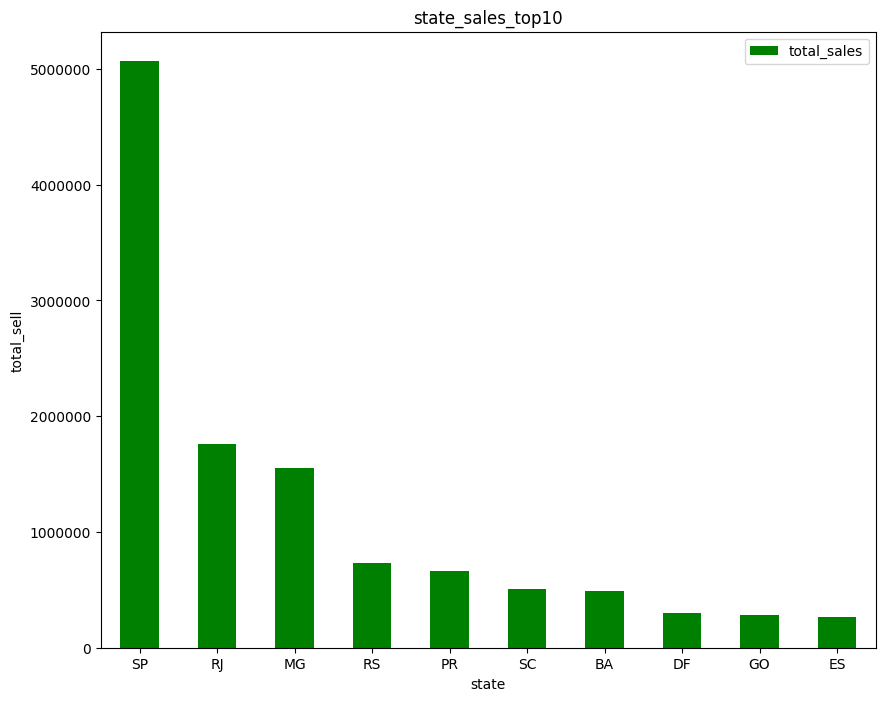

In [148]:
ax = state_sales_top10.plot(kind='bar',x='customer_state',y='total_sales',figsize=(10,8),color='green')
plt.ticklabel_format(axis='y',style='plain',useOffset=False)
plt.xticks(rotation=0);
ax.set_xlabel('state')
ax.set_ylabel('total_sell')
ax.set_title('state_sales_top10')

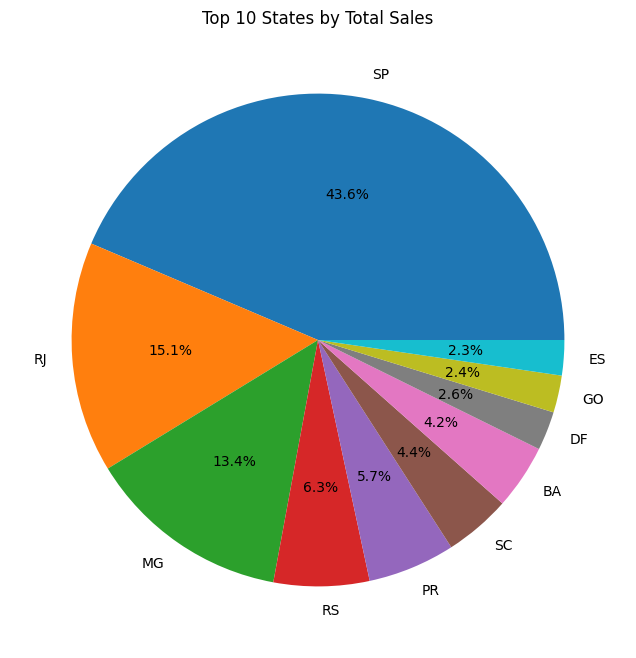

In [150]:
state_sales_top10.set_index('customer_state')['total_sales'].plot(
    kind='pie',
    figsize=(8, 8),
    autopct='%.1f%%'
)

plt.ylabel('')
plt.title('Top 10 States by Total Sales')
plt.show()

In [158]:
state_order_df = state_order.reset_index()
state_order_df.columns = ['customer_state', 'order_count']

state_compare = pd.merge(state_order_df, state_sales, on='customer_state')
state_compare['avg_order_sales'] = state_compare['total_sales'] / state_compare['order_count']
state_compare.sort_values('avg_order_sales', ascending=False).head(10)
x = state_compare.sort_values('avg_order_sales', ascending=False).head(10)
x

,customer_state,order_count,total_sales,sale_pct,avg_order_sales
16,PB,536,112586.82,0.01,210.05
25,AP,68,13374.81,0.00,196.69
24,AC,81,15930.97,0.00,196.68
19,AL,413,78855.72,0.01,190.93
22,RO,253,45682.76,0.00,180.56
12,PA,975,174470.59,0.01,178.94
21,TO,280,48402.51,0.00,172.87
17,PI,495,84721.00,0.01,171.15
18,RN,485,82105.66,0.01,169.29
13,MT,907,152191.62,0.01,167.80


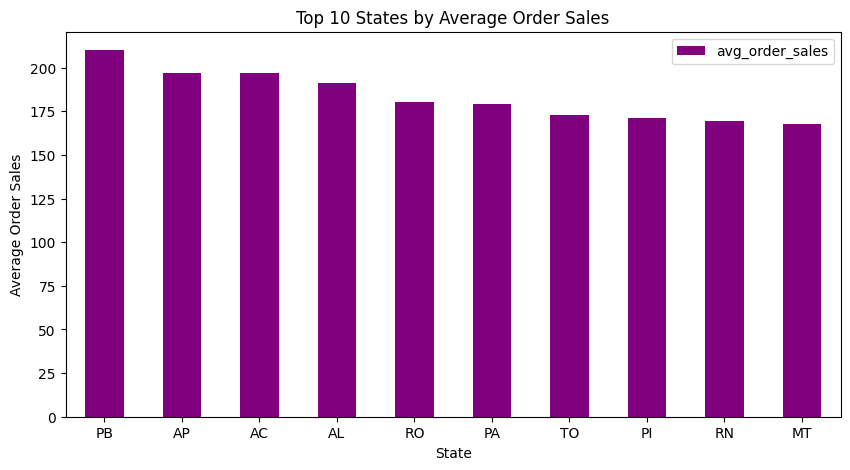

In [159]:
ax = x.plot(
    x='customer_state',
    y='avg_order_sales',
    kind='bar',
    figsize=(10, 5),
    color='purple'
)

ax.ticklabel_format(style='plain', axis='y')
plt.xlabel('State')
plt.ylabel('Average Order Sales')
plt.title('Top 10 States by Average Order Sales')
plt.xticks(rotation=0)
plt.show()

### 各州平均订单金额分析

进一步将各州销售额与订单数结合，可以得到各州的平均订单金额。结果显示，平均订单金额最高的州并不是订单占比最高的州，说明地区之间的消费结构存在明显差异。

从订单占比分布来看，`SP`、`RJ`、`MG` 是平台订单最集中的核心州，尤其 `SP` 州订单占比远高于其他地区，说明平台订单规模高度集中在头部州。

但从平均订单金额来看，排名靠前的州主要是 `PB`、`AP`、`AC`、`AL` 等州，这些州并未出现在订单占比前列，说明它们虽然订单规模相对较小，但单笔订单金额相对更高。

这表明地区分析不能只关注订单数量，还应结合销售额和平均订单金额综合判断。部分州属于“订单规模型”市场，而另一些州则更偏向“高客单价型”市场。


In [165]:
products = pd.read_csv('olist_products_dataset.csv')
products_translation = pd.read_csv('product_category_name_translation.csv')
products.to_sql('products', conn, index=False, if_exists='replace')
products_translation.to_sql('products_translation',conn,index=False,if_exists='replace')

71

In [166]:
display(order_items.head(),
        products.head(),
        products_translation.head())
        

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [188]:
query = '''
SELECT
    pt.product_category_name_english AS category_name,
    COUNT(*) AS sales_count
FROM order_items AS oi
LEFT JOIN products AS p
    ON oi.product_id = p.product_id
LEFT JOIN products_translation AS pt
    ON p.product_category_name = pt.product_category_name
GROUP BY pt.product_category_name_english
ORDER BY sales_count DESC
'''
category_sales = pd.read_sql(query, conn)
category_sales.head(20)


,category_name,sales_count
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
5,housewares,6964
6,watches_gifts,5991
7,telephony,4545
8,garden_tools,4347
9,auto,4235


Text(0.5, 1.0, 'category_sales_count')

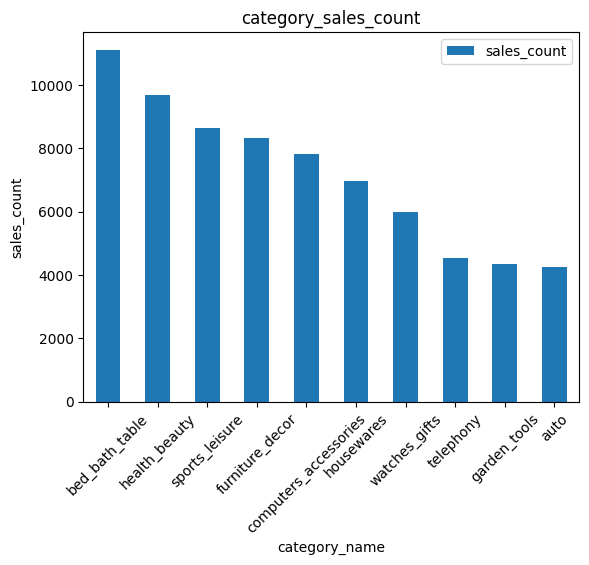

In [200]:
category_sales_top10 = category_sales.head(10)
ax = category_sales_top10.plot(kind='bar',x='category_name',y='sales_count')
ax.set_xlabel('category_name')
ax.set_ylabel('sales_count')
plt.xticks(rotation=45);
ax.set_title('category_sales_count')

In [198]:
query = '''
SELECT
    pt.product_category_name_english AS category_name,
    SUM(oi.price) AS total_sales
FROM order_items AS oi
LEFT JOIN products AS p
    ON oi.product_id = p.product_id
LEFT JOIN products_translation AS pt
    ON p.product_category_name = pt.product_category_name
GROUP BY pt.product_category_name_english
ORDER BY total_sales DESC
'''
total_sales = pd.read_sql(query, conn)
total_sales.head(20)


,category_name,total_sales
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


Text(0.5, 1.0, 'category_sales')

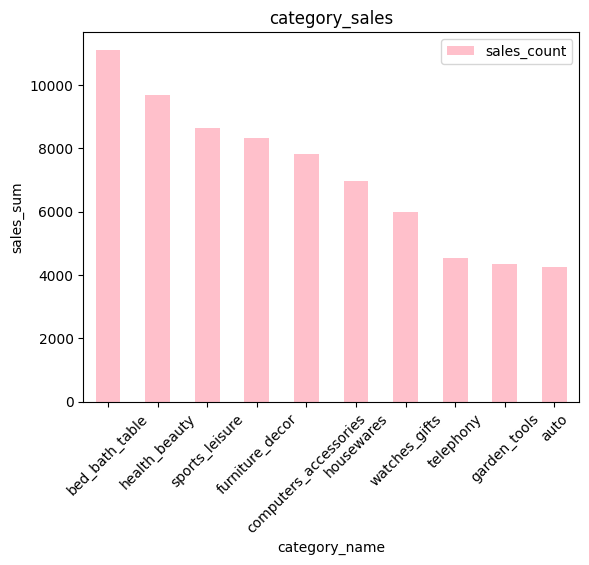

In [202]:
total_sales_top10 = category_sales.head(10)
ax = total_sales_top10.plot(kind='bar',x='category_name',y='sales_count',color='pink')
ax.set_xlabel('category_name')
ax.set_ylabel('sales_sum')
plt.xticks(rotation=45);
ax.set_title('category_sales')

In [203]:
display(category_sales.head(10),total_sales.head())

,category_name,sales_count
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
5,housewares,6964
6,watches_gifts,5991
7,telephony,4545
8,garden_tools,4347
9,auto,4235


,category_name,total_sales
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32


In [205]:
x = pd.merge(category_sales,total_sales,on='category_name',how='inner')
x

,category_name,sales_count,total_sales
0,bed_bath_table,11115,1036988.68
1,health_beauty,9670,1258681.34
2,sports_leisure,8641,988048.97
3,furniture_decor,8334,729762.49
4,computers_accessories,7827,911954.32
...,...,...,...
67,arts_and_craftmanship,24,1814.01
68,la_cuisine,14,2054.99
69,cds_dvds_musicals,14,730.00
70,fashion_childrens_clothes,8,569.85


In [209]:
y = x.head(10)
y['avg_sales'] = x['total_sales'] / x['sales_count']
y.sort_values(['avg_sales'],ascending=False)

,category_name,sales_count,total_sales,avg_sales
6,watches_gifts,5991,1205005.68,201.14
9,auto,4235,592720.11,139.96
1,health_beauty,9670,1258681.34,130.16
4,computers_accessories,7827,911954.32,116.51
2,sports_leisure,8641,988048.97,114.34
8,garden_tools,4347,485256.46,111.63
0,bed_bath_table,11115,1036988.68,93.30
5,housewares,6964,632248.66,90.79
3,furniture_decor,8334,729762.49,87.56
7,telephony,4545,323667.53,71.21


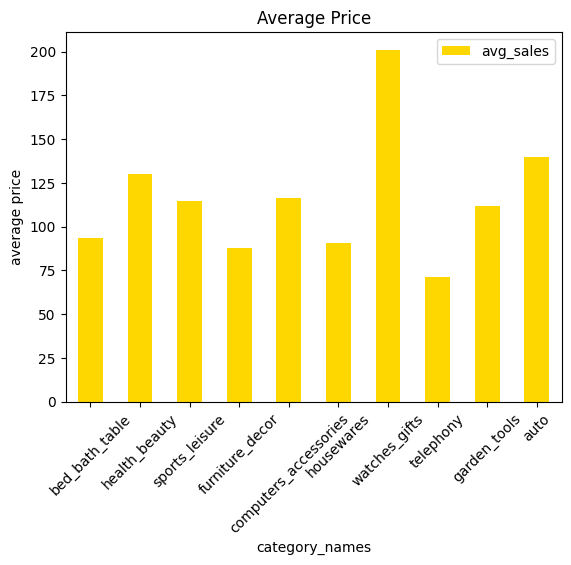

In [216]:
z = y.head(10)
z.plot(kind='bar',x='category_name',y='avg_sales',color='gold',ylabel='average price',xlabel='category_names',
       title='Average Price')
plt.xticks(rotation=45);

### 商品类别平均价格分析

在比较商品类别销量和销售额之后，进一步计算各类别商品的平均价格，可以更清楚地区分“高销量品类”和“高单价品类”。

结果显示，`watches_gifts` 的平均价格最高，说明该类别更偏向高客单价商品，虽然销量不一定处于绝对领先位置，但单件商品价格明显更高。`auto`、`health_beauty`、`computers_accessories` 等类别的平均价格也相对较高，说明这些类别在金额贡献上具有一定优势。

相比之下，`bed_bath_table` 虽然在销量和销售额上都处于领先位置，但平均价格并不是最高，说明该类别更多依赖销量规模带动总销售额增长，属于典型的“销量驱动型”核心品类。

综合来看，平台头部商品类别可以进一步分为两类：一类是依靠高销量贡献收入的核心品类，另一类是依靠较高单价提升金额规模的高客单价品类。


## 评论分析

In [225]:
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
display(reviews.head(5),
        orders.head())

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
query = '''
WITH review AS (
    SELECT 
        review_score,
        COUNT(review_score) AS star,
        order_id
    FROM 
        reviews
GROUP BY review_score,order_id
)
SELECT
    r.review_score,
    SUM(r.star)
FROM orders AS o
INNER JOIN 
    review AS r
ON r.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY r.review_score
;

'''

In [250]:
query1 = '''
SELECT 
    r.review_score,
    COUNT(r.review_score) AS star_count
FROM 
    reviews AS r
INNER JOIN
    orders AS o
ON  r.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY r.review_score

'''

In [258]:
reviews_sum = pd.read_sql(query1,conn)
reviews_sum['star_pct'] =reviews_sum['star_count'] / reviews_sum['star_count'].sum()
reviews_sum = reviews_sum.sort_values(by='star_pct',ascending=False)
reviews_sum


,review_score,star_count,star_pct
4,5,57066,0.59
3,4,18987,0.20
0,1,9406,0.10
2,3,7961,0.08
1,2,2941,0.03


In [ ]:
state_sales_top10.set_index('customer_state')['total_sales'].plot(
    kind='pie',
    figsize=(8, 8),
    autopct='%.1f%%'
)

plt.ylabel('')
plt.title('Top 10 States by Total Sales')
plt.show()

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '5'),
  Text(1, 0, '4'),
  Text(2, 0, '1'),
  Text(3, 0, '3'),
  Text(4, 0, '2')])

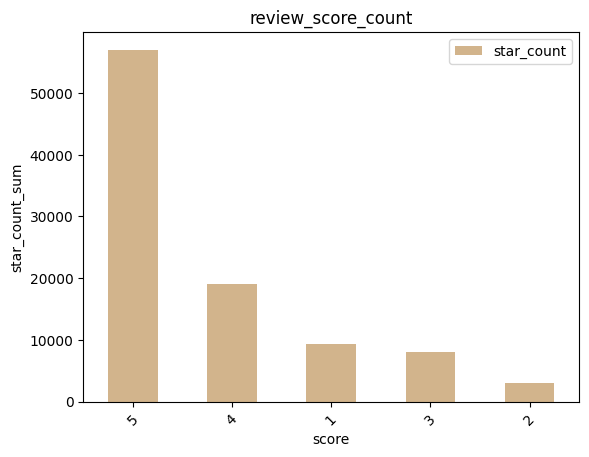

In [268]:

reviews_sum.plot(kind='bar',x='review_score',y='star_count',color='tan',xlabel='score',ylabel='star_count_sum',title='review_score_count')
plt.xticks(rotation=45)

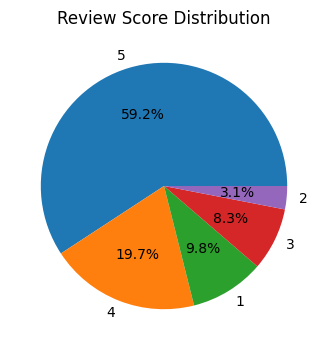

In [269]:
reviews_sum.set_index('review_score')['star_count'].plot(
    kind='pie',
    figsize=(4, 4),
    autopct='%.1f%%'
)

plt.ylabel('')
plt.title('Review Score Distribution')
plt.show()


### 评分分布分析

从评分分布来看，平台评价整体偏向高分，其中 `5` 分评价占比最高，约为 `59.2%`，`4` 分评价占比约为 `19.7%`。这说明大部分用户对平台订单体验持较为正面的态度，整体满意度较高。

但与此同时，`1` 分评价占比约为 `9.8%`，说明平台仍存在一定比例的明显负面评价用户，低分评价不可忽视。相比之下，`2` 分和 `3` 分评价占比相对较低，中间分值并不集中。

整体来看，平台评分结构呈现出明显的高分集中现象，同时也存在一定程度的低分聚集，表现出一定的“两极化”特征。这意味着多数用户体验较好，但仍有一部分订单在履约或服务环节上可能存在明显问题。


## 评分与物流时效的关系分析



In [272]:
display(orders.head(),
        reviews.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [284]:
query = '''
SELECT 
    r.review_score,
    AVG(julianday(order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) AS avg_delivered_date
FROM 
    reviews AS r
INNER JOIN 
    orders AS o
ON 
    o.order_id = r.order_id
WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    AND o.order_purchase_timestamp IS NOT NULL
    AND r.review_score IS NOT NULL
GROUP BY r.review_score;
'''
score_delivery = pd.read_sql(query,conn)
score_delivery

,review_score,avg_delivered_date
0,1,21.31
1,2,16.66
2,3,14.26
3,4,12.31
4,5,10.69


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5')])

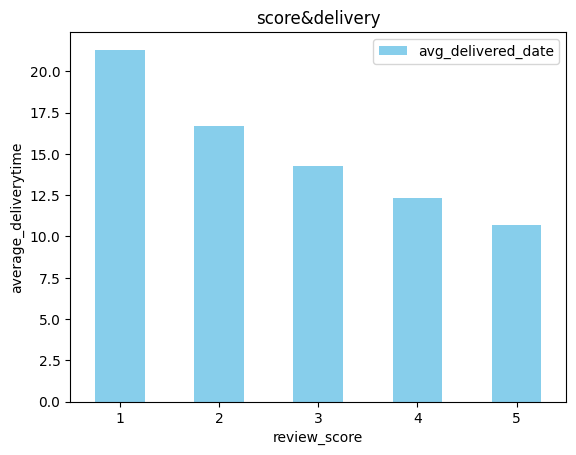

In [ ]:
score_delivery.plot(kind='bar',x='review_score',y='avg_delivered_date',color='skyblue',
                    xlabel='review_score',ylabel='average_deliverytime',title='score&delivery')
plt.xticks(rotation=0);


### 评分与配送时长关系分析

进一步将订单评分与配送时长联系起来可以发现，不同评分对应的平均配送天数存在明显差异。

从结果看，`1` 分订单的平均配送时长最长，而 `5` 分订单的平均配送时长最短，整体呈现出“评分越低，配送时间越长”的趋势。这说明评分与物流时效之间存在较明显的负相关关系。

这一现象表明，物流配送速度很可能是影响用户评价的重要因素之一。对于配送时间较长的订单，用户更容易给出较低评分；而配送体验更顺畅的订单，则更容易获得较高评价。

综合来看，订单履约效率不仅影响物流表现本身，也会进一步影响用户满意度和平台整体评价结构。


## 项目总结

本项目基于 Olist 巴西电商数据集，从订单、销售额、支付、用户、地区、商品类别和用户评价等多个角度，对平台业务进行了系统分析。

首先，从整体业务规模看，平台订单量较大，且订单状态以 `delivered` 为主，说明大多数订单最终能够完成履约。月度订单趋势和销售额趋势整体呈现先增长后波动的变化，反映出平台业务在样本时间范围内经历了明显扩张，并在后期趋于稳定。

在金额分析方面，商品销售额与“商品金额+运费”的趋势整体一致，说明运费会抬高订单总金额，但并没有改变整体销售走势。进一步分析发现，个别月份运费占比偏高，主要与该阶段样本量较小有关，因此在解读比例指标时需要结合业务规模一起判断。

在支付分析中，平台支付方式以信用卡为主，无论是支付记录数还是支付金额，信用卡都占据主导地位。进一步对信用卡分期情况分析后发现，`1` 期支付最常见，说明用户总体更偏向一次性支付或低分期支付；但分期数越高，平均支付金额整体呈上升趋势，说明高分期方式更多出现在高金额订单中。

在用户分析中，平台真实用户数应以 `customer_unique_id` 为准。结果显示，平台复购率约为 `3%`，说明绝大多数用户只完成一次购买，平台整体以一次性购买用户为主，用户复购程度相对较低。用户下单次数分布也进一步验证了这一点，整体呈现出明显的长尾结构。

在地区分析中，平台订单和销售额都表现出明显的地区集中性。`SP` 州订单占比最高，是平台最核心的订单来源地；进一步下钻到州内城市后发现，`sao paulo` 市在 `SP` 州内部也处于绝对领先地位，说明平台订单在地区上具有明显的层级集中性。同时，不同州在平均订单金额上的表现并不一致，表明有些州属于“订单规模型”市场，而有些州则更偏向“高客单价型”市场。

在商品类别分析中，`bed_bath_table`、`health_beauty`、`sports_leisure`、`furniture_decor` 等类别在销量和销售额上都表现突出，是平台核心成交品类。进一步结合平均价格分析发现，`watches_gifts`、`auto` 等类别虽然销量未必最高，但平均价格较高，属于高客单价品类。这说明平台头部品类既包括依靠销量驱动的核心品类，也包括依靠较高单价贡献金额的品类。

在评价分析中，平台整体评分偏高，`5` 分和 `4` 分评价占据主要比例，说明大多数用户对购物体验持正面态度。但与此同时，`1` 分评价仍占有一定比例，说明平台仍存在不可忽视的负面体验订单。进一步将评分与配送时长结合分析后发现，评分越低，平均配送时长越长，表明物流履约效率很可能是影响用户满意度的重要因素之一。

综合来看，Olist 平台的业务具有以下几个明显特征：第一，订单和销售额主要集中在少数核心州和核心城市；第二，平台支付方式以信用卡为主，低分期支付占主流；第三，用户整体复购率较低，订单更多依赖一次性购买用户；第四，平台核心成交由少数头部商品类别支撑；第五，物流时效对用户评分具有较明显影响。

如果后续继续深入，可以进一步围绕卖家分布、品类评价差异、地区物流表现等方向展开分析，以更完整地理解平台业务结构与用户体验之间的关系。
